#### EDA
Este archivo va a explorar los contenido de los datos.

Adicionalmente creara los feature engineering para crear los modelos.

Parte de este archivo tambien va a ser como poder usar los datos para poder desarrollar los siguiete variables:
- $K$ = numero de clusters/segmentos de touristas
- $N_k$ = numero de touristas dentro segmento $k$
- $p_k$ = probabilidad que un tourista dentro segmente $k$ responda positivamente a una campana de marketing
- $r_k$ = ingreso promedio de un tourista en segmento $k$ si responden al marketing
- $c_k$ = costo de marketing para un tourista en segmento $k$

Los variables $K$ y $N_k$ se van a solucionar con metodo de clustering.
- Datos necesarios: Visitantes internacionales
    * Numero de turistas?
    * Tratar de ver los sitios mas probables que visiten
        - Aunque no creo que tengo los datos disponibles para ese objetivo

El variable $p_k$ se va a solucion con regresion binaria.
- Tratar de buscar ver cuanto de los turistas (dentro de segmento k) se van a lugares turisticos y cuantos solo se quedan en su hospedaje.

El variable $r_k$ se va a solucionar con el metodo de regresion.
- Datos necesarios: Inventario de recurss turisticos
    * Tratar de separar los lugares turisticos por segmento
    * Despues se puede asignar un promedio: (suma de ingresos de sitios en segmento k) / (numero de sitios en segmento k)

El variable $c_k$ se va a solcuionar con metodo de regresion
- Revisiando cuanto es el promedio de diner que el gobierno invierte en departmento de turimso
- Tratar de ver cuanto cada sitio cuesta para mantenimiento
    * Ende: (suma de costo de mantenimiento de sitios en segmento k) / (numero de sitios en segmento k)

In [2]:
##### Importacion de modulos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

##### Cambiando directorias
cwd = os.getcwd()
if cwd.split('\\')[-1] != 'Limpios': os.chdir('./Datos/Limpios')
print(os.getcwd())

##### Nombre de archivos
nom_1 = 'visitantes_internacionales.csv'
nom_2 = 'visitantes_sitios_turisticos.csv'
nom_3 = 'inventario_recursos_turisticos.csv'

c:\Users\JP\Documents\DSProyectos\3_SegmentacionClientes\Datos\Limpios


##### EDA Datos 1: Visitantes internacionales

In [3]:
##### Cargando datos
df_1 = pd.read_csv(nom_1)
df_1.head()

,FECHA_CORTE,ANIO,ID_MES,MES,ID_PAIS,PAIS,ID_CONTINENTE,CONTINENTE,ID_OCM,OCM,DEPARTAMENTO_OCM,NUMERO_VISITANTES,TIPO_VISITANTE
0,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,1,AEROPUERTO INTERNACIONAL JORGE CHÁVEZ,LIMA Y CALLAO,698,TURISTAS
1,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,2,SANTA ROSA,TACNA,32,TURISTAS
2,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,3,DESAGUADERO,PUNO,72,TURISTAS
3,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,4,KASANI,PUNO,27,TURISTAS
4,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,5,CEBAF - TUMBES,TUMBES,38,TURISTAS


In [4]:
##### Resumen breve
df_1.info()

##### Eliminando columnas no necesarias
df_1 = df_1.drop(columns=['FECHA_CORTE', 'MES', 'TIPO_VISITANTE'])

<class 'pandas.DataFrame'>
RangeIndex: 199584 entries, 0 to 199583
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   FECHA_CORTE        199584 non-null  int64
 1   ANIO               199584 non-null  int64
 2   ID_MES             199584 non-null  int64
 3   MES                199584 non-null  str  
 4   ID_PAIS            199584 non-null  int64
 5   PAIS               199584 non-null  str  
 6   ID_CONTINENTE      199584 non-null  int64
 7   CONTINENTE         199584 non-null  str  
 8   ID_OCM             199584 non-null  int64
 9   OCM                199584 non-null  str  
 10  DEPARTAMENTO_OCM   199584 non-null  str  
 11  NUMERO_VISITANTES  199584 non-null  int64
 12  TIPO_VISITANTE     199584 non-null  str  
dtypes: int64(7), str(6)
memory usage: 19.8 MB


In [5]:
###### Separando variables categoricales y numericas
df_1.info()
cuant_vars_1 = df_1._get_numeric_data().columns.values
cual_vars_1 = list(set(df_1.columns)- set(cuant_vars_1))

<class 'pandas.DataFrame'>
RangeIndex: 199584 entries, 0 to 199583
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ANIO               199584 non-null  int64
 1   ID_MES             199584 non-null  int64
 2   ID_PAIS            199584 non-null  int64
 3   PAIS               199584 non-null  str  
 4   ID_CONTINENTE      199584 non-null  int64
 5   CONTINENTE         199584 non-null  str  
 6   ID_OCM             199584 non-null  int64
 7   OCM                199584 non-null  str  
 8   DEPARTAMENTO_OCM   199584 non-null  str  
 9   NUMERO_VISITANTES  199584 non-null  int64
dtypes: int64(6), str(4)
memory usage: 15.2 MB


In [6]:
# df_1[df_1['NUMERO_VISITANTES']!=0]['NUMERO_VISITANTES'].value_counts()

# .describe()
# .boxplot(column='NUMERO_VISITANTES')

,ANIO,ID_MES,ID_PAIS,ID_CONTINENTE,ID_OCM,NUMERO_VISITANTES
count,199584.000000,199584.000000,199584.000000,199584.000000,199584.000000,199584.000000
mean,2022.000000,6.500000,99.500000,4.671717,3.500000,102.444304
std,2.000005,3.452061,57.157091,1.523658,1.707829,1601.486329
min,2019.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2020.000000,3.750000,50.000000,4.000000,2.000000,0.000000
50%,2022.000000,6.500000,99.500000,5.000000,3.500000,0.000000
75%,2024.000000,9.250000,149.000000,6.000000,5.000000,0.000000
max,2025.000000,12.000000,198.000000,11.000000,6.000000,94883.000000


graph for PAIS: total = 198


C:\Users\JP\AppData\Local\Temp\ipykernel_7776\1230033410.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


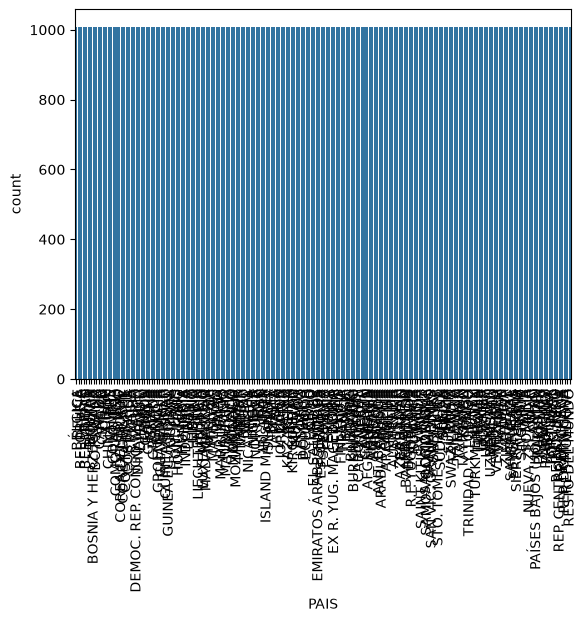

graph for DEPARTAMENTO_OCM: total = 5


C:\Users\JP\AppData\Local\Temp\ipykernel_7776\1230033410.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


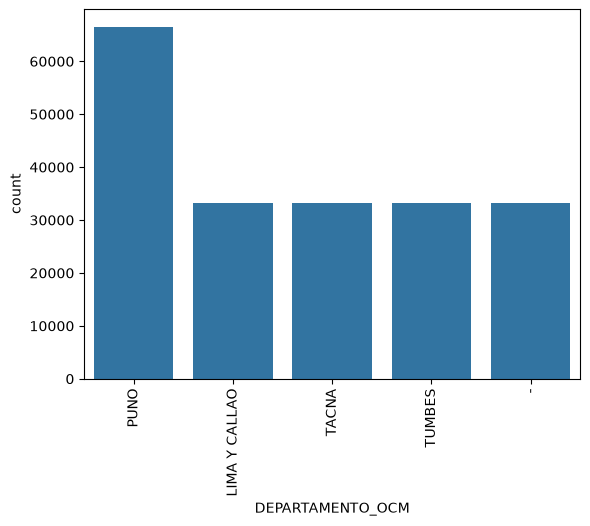

graph for CONTINENTE: total = 8


C:\Users\JP\AppData\Local\Temp\ipykernel_7776\1230033410.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


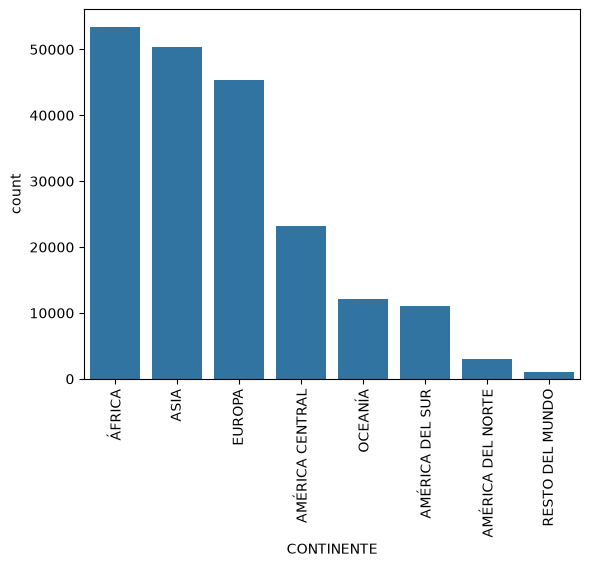

graph for OCM: total = 6


C:\Users\JP\AppData\Local\Temp\ipykernel_7776\1230033410.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


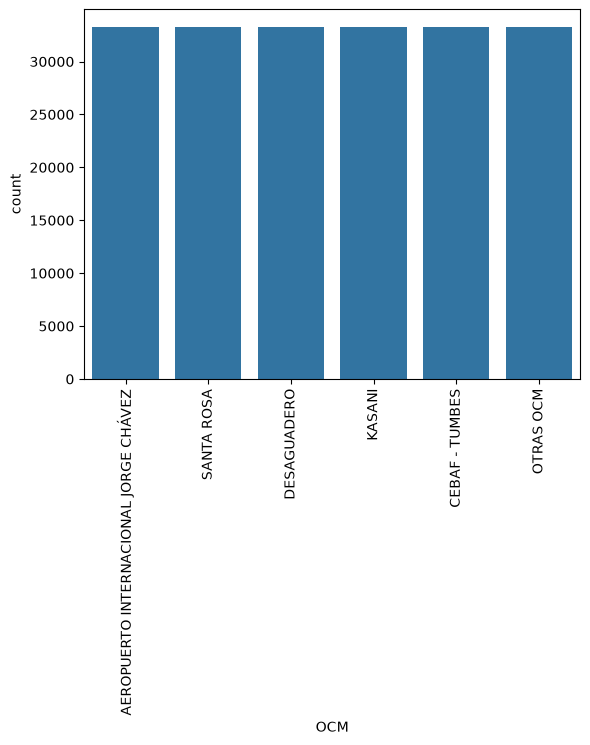

In [8]:
##### Analizando datos
#### Cuant
display(df_1[cuant_vars_1].describe())

#### Cual
for col in cual_vars_1:
    cat_num = df_1[col].value_counts()[:]
    print("graph for %s: total = %d" % (col, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

In [ ]:
##### Analisis mas profundo
#### ANIO
# df_1['ANIO'].value_counts()

#### ID_MES
# df_1['ID_MES'].value_counts()

#### ID_PAIS
# df_1['ID_PAIS'].value_counts()
# len(df_1['ID_PAIS'].value_counts().to_dict().keys())

#### ID_CONTINENTE
# df_1['ID_CONTINENTE'].value_counts()

#### ID_OCM
# df_1['ID_OCM'].value_counts()

#### DEPARTAMENTO_OCM
# df_1['DEPARTAMENTO_OCM'].value_counts()

#### NUMERO_VISITANTES
# df_1['NUMERO_VISITANTES'].describe()
# df_1['NUMERO_VISITANTES'].value_counts()
# df_1.info()
# df_1[df_1['NUMERO_VISITANTES'] > 100].info()
# df_1[(df_1['NUMERO_VISITANTES'] <= 100) & (df_1['NUMERO_VISITANTES'] > 50)].info()
# df_1[(df_1['NUMERO_VISITANTES'] <= 50) & (df_1['NUMERO_VISITANTES'] > 25)].info()
# df_1[df_1['NUMERO_VISITANTES'] <= 25].info()

NUMERO_VISITANTES
0        158250
1          7896
2          4056
3          2535
4          1948
          ...  
1382          1
45502         1
964           1
3333          1
1872          1
Name: count, Length: 2860, dtype: int64

### Analisis de Datos 1

Analisis por columna:
* ANIO
    - Rango: 2019 - 2025
    - Hay 28512 registros en cada uno de los 7 anios
* ID_MES
    - Rango: 1 - 12
    - Hay 16632 registros en cada uno de los 12 meses
* ID_PAIS
    - Existen 198 distincto paises con valores de 1 - 198
    - Hay 1008 registros por cada pais
        - => Cada pais aparece 1008 veces en el conjunto
        - 7 anios * 12 meses * 6 OCMs * 2 tipos de visitantes = 1008
* PAIS
    - Nombre de los paises (1-1 correspondencia)
* ID_CONTINENTE
    - Existen 8 continentes 
    - Hay las siguiente variaciones:
        * Africa: 53424
        * Asia: 50400
        * Europa: 45360
        * America Central: 23184
        * Oceania: 12096
        * America del Sur: 11088
        * America del Norte: 3024
        * Resto: 1008
* CONTINENTE
    - Nombre de los id de los paises
* ID_OCM
    - Existen 6 OCMS
        * Aueropuerto Internacional (Lima)
        * Santa Rosa
        * Desguadero (Puno)
        * Kasani (Puno)
        * Cebaf-Tumbes (Tumbes)
        * Otras
    - Las 6 OCMs tienen 33264 registros cada una
* OCM
    * Nombres de los OCMs
* DEPARTAMENTO_OCM
    - Hay las siguiente variaciones:
        * Puno: 66528 = 33264 * 2
        * Lima y Callao: 33264
        * Tacna: 33264
        * Tumbes: 33264
        * Otros: 33264
* NUMERO_VISITANTES
    - Este es una columna extrana
    - (min, mean, median, max) = (0, 100, 0, 94883)
    - Estos datos son right skewed extremadamente
        * Evidencia: mean = 100 y median = 0
    - Existen 199584 registros
        * 7732 registros tienen 'NUMERO_VISITANTES' > 100
        * 2261 registros tienen 'NUMER_VISITANTES' entre (50,100]
        * 3227 resgitros tienen 'NUMERO_VISITANTES' entre (25,50]
        * 185964 registros tienen 'NUMERO_VISITANTES' entre [0,25]
    - Detalle de frecuencias 'NUMERO_VISITANTES' en {0,1,2,3,4,5,6,7}
        * 0 visitantes: 158250 veces
        * 1 visitante: 7896 veces
        * 2 vistantes: 4056 veces
        * 3 visitantes: 2535 veces
        * 4-7 visitantes: entre 1000 - 2000 veces
        * 8 - 12 visitantes: entre 500 - 1000 veces
        * 13+ vistantes: menos de 500 veces
    - En otras palabras, la mayoria de los sitios turisticos solo tienen pocos visitantes
        * Tambien, esto es a traves de los 7 anios
        * Pero no cambia el hecho que la mayoria tienen 0 visitantes



#### EDA Datos 2: Visitantes a sitios

#### EDA 3: Inventarios de recursos turisticos

In [ ]:
##### Cargando datos
df_3 = pd.read_csv(nom_3)
df_3.head()

,REGIÓN,PROVINCIA,DISTRITO,CODIGO DEL RECURSO,NOMBRE DEL RECURSO,CATEGORÍA,TIPO DE CATEGORÍA,SUB TIPO CATEGORÍA,URL,LATITUD,LONGITUD,FECHA_DE_CORTE,TIPO,OBSERVACION
0,Cusco,Cusco,CUSCO,11,Festividad Del Señor De Los Temblores,5. ACONTECIMIENTOS PROGRAMADOS,Fiestas,Fiestas religiosas-patronales,https://consultasenlinea.mincetur.gob.pe/ficha...,-71.980100,-13.515300,20260727,Libre,Libre
1,Cajamarca,Contumaza,YONAN,16,Petroglifos De Yonan,2. MANIFESTACIONES CULTURALES,Sitios Arqueológicos,Petroglifos (Grabados en piedra),https://consultasenlinea.mincetur.gob.pe/ficha...,-79.130786,-7.253108,20260727,Libre,Libre
2,Amazonas,Chachapoyas,LEVANTO,17,Sitio Arqueológico De Collacruz,2. MANIFESTACIONES CULTURALES,Sitios Arqueológicos,Zonas arqueológicas,https://consultasenlinea.mincetur.gob.pe/ficha...,-77.907014,-6.310458,20260727,Libre,El recurso se encuentra junto a la carretera q...
3,Huánuco,Lauricocha,SAN MIGUEL DE CAURI,22,Laguna De Lauricocha,1. SITIOS NATURALES,g. Cuerpo de Agua,Lagunas,https://consultasenlinea.mincetur.gob.pe/ficha...,-76.663890,-10.315822,20260727,Previa presentación de boleto o ticket(especif...,Compra de boleto para acceso a tres atractivos...
4,Huánuco,Lauricocha,QUEROPALCA,24,Nevado De Yerupajá De Queropalca,1. SITIOS NATURALES,a. Montañas,Nevado,https://consultasenlinea.mincetur.gob.pe/ficha...,-76.905235,-10.268424,20260727,Previa presentación de boleto o ticket(especif...,"Se paga el ingreso al pueblo de Queropalca, S/..."


In [ ]:
##### Resumen breve
df_3.info()

##### Eliminando columnas que no son necesarias
df_3 = df_3.drop(columns=['URL', 'LATITUD', 'LONGITUD', 'FECHA_DE_CORTE'])


<class 'pandas.DataFrame'>
RangeIndex: 4556 entries, 0 to 4555
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   REGIÓN              4556 non-null   str    
 1   PROVINCIA           4556 non-null   str    
 2   DISTRITO            4556 non-null   str    
 3   CODIGO DEL RECURSO  4556 non-null   int64  
 4   NOMBRE DEL RECURSO  4556 non-null   str    
 5   CATEGORÍA           4556 non-null   str    
 6   TIPO DE CATEGORÍA   4556 non-null   str    
 7   SUB TIPO CATEGORÍA  4556 non-null   str    
 8   URL                 4556 non-null   str    
 9   LATITUD             4539 non-null   float64
 10  LONGITUD            4539 non-null   float64
 11  FECHA_DE_CORTE      4556 non-null   int64  
 12  TIPO                4556 non-null   str    
 13  OBSERVACION         4556 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 498.4 KB


In [ ]:
###### Separando variables categoricales y numericas
cuant_vars_3 = df_3._get_numeric_data().columns.values
cual_vars_3 = list(set(df_3.columns)- set(cuant_vars_3))

graph for NOMBRE DEL RECURSO: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11476\3032993046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


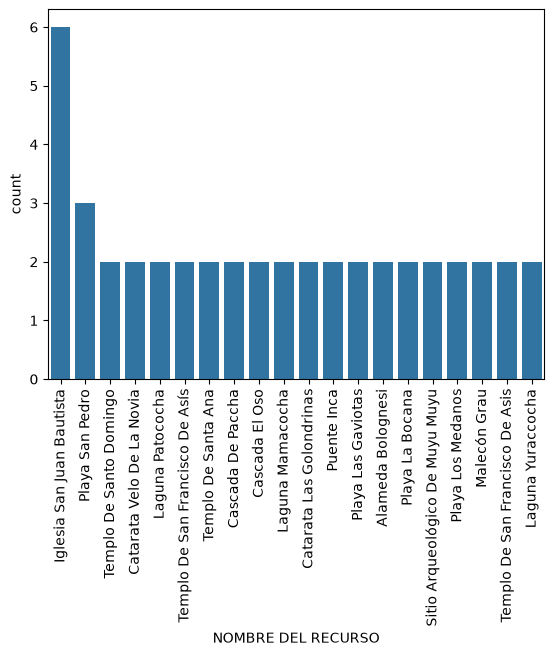

graph for TIPO DE CATEGORÍA: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11476\3032993046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


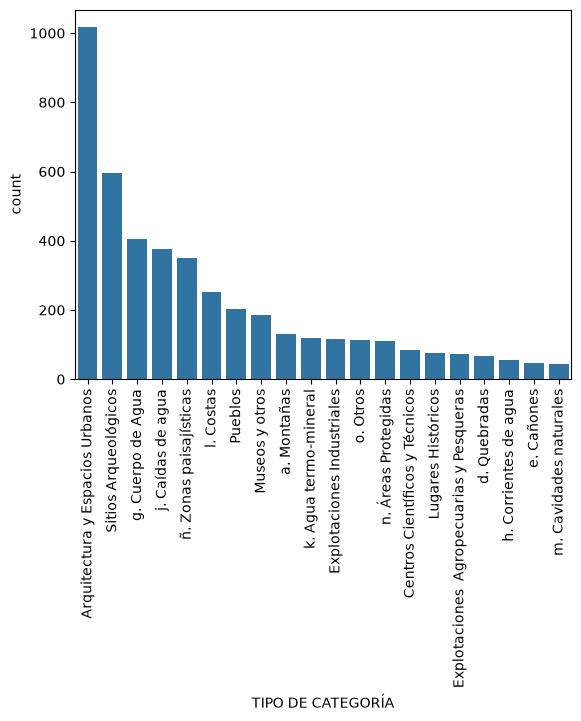

graph for SUB TIPO CATEGORÍA: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11476\3032993046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


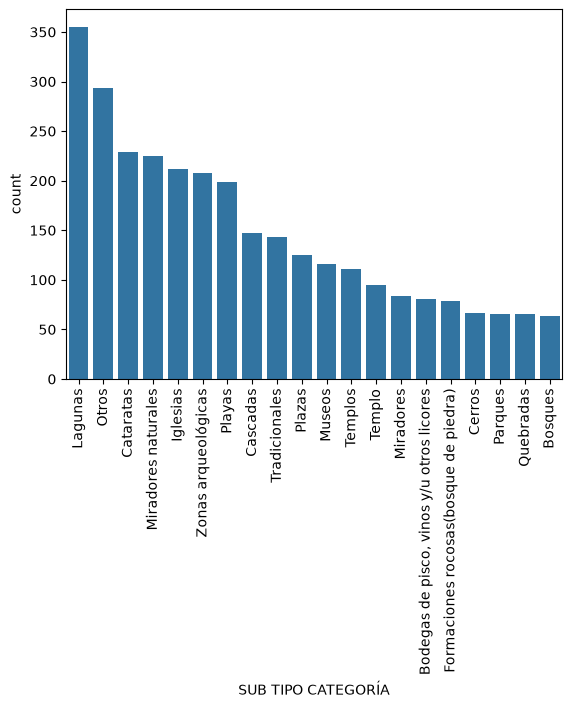

graph for DISTRITO: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11476\3032993046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


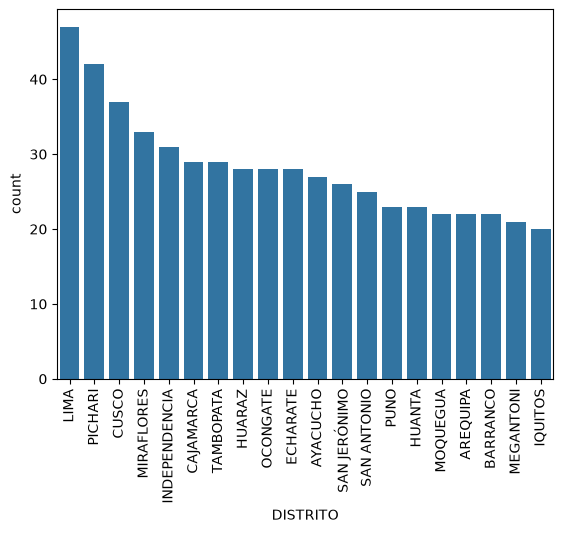

graph for TIPO: total = 16


C:\Users\JP\AppData\Local\Temp\ipykernel_11476\3032993046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


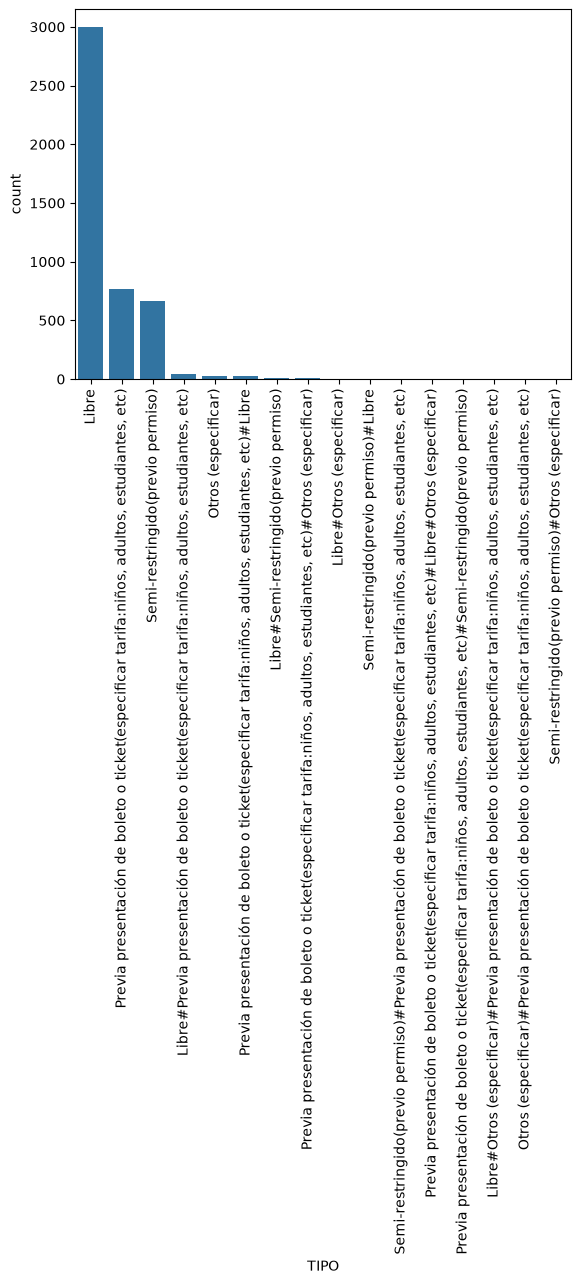

graph for OBSERVACION: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11476\3032993046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


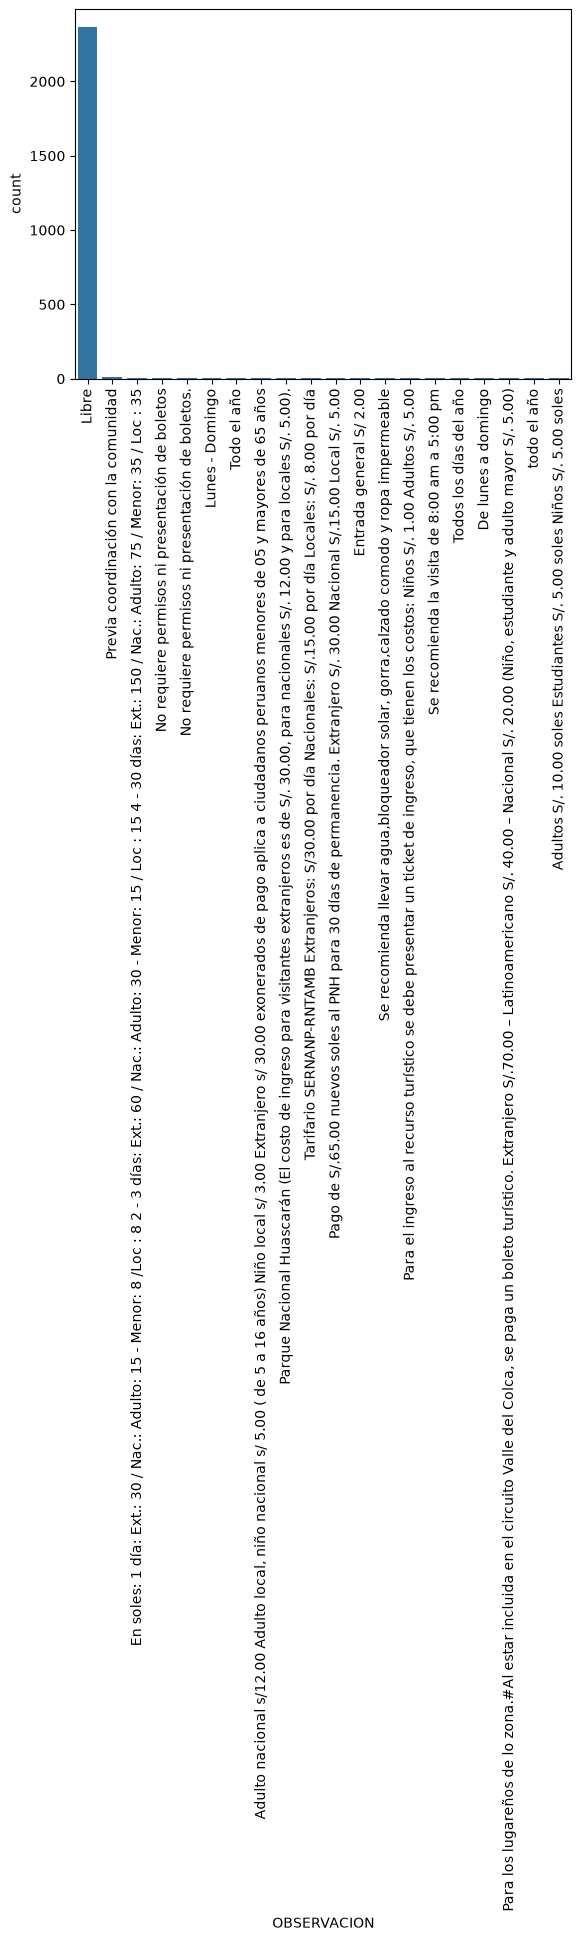

graph for CATEGORÍA: total = 5


C:\Users\JP\AppData\Local\Temp\ipykernel_11476\3032993046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


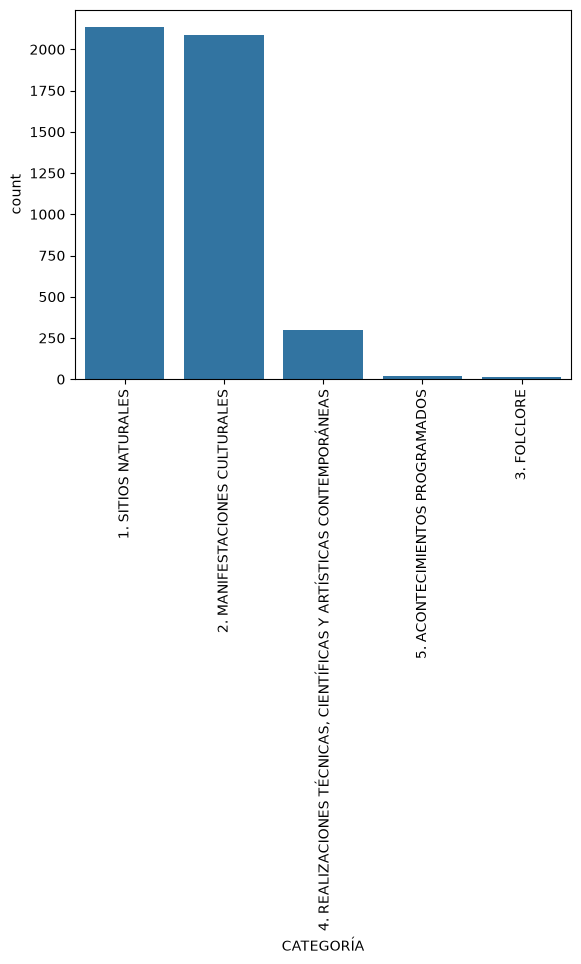

graph for PROVINCIA: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11476\3032993046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


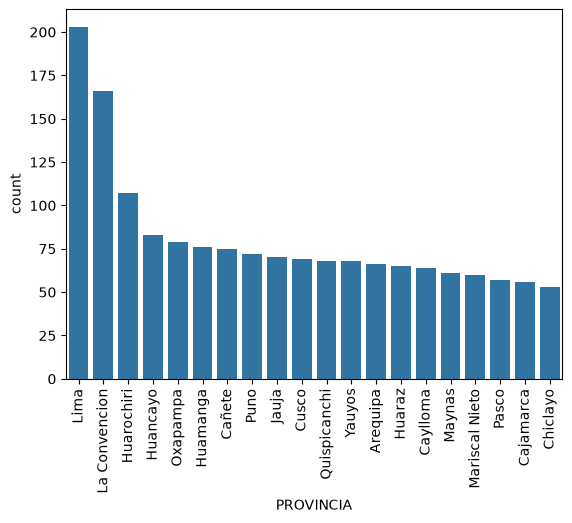

graph for REGIÓN: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11476\3032993046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


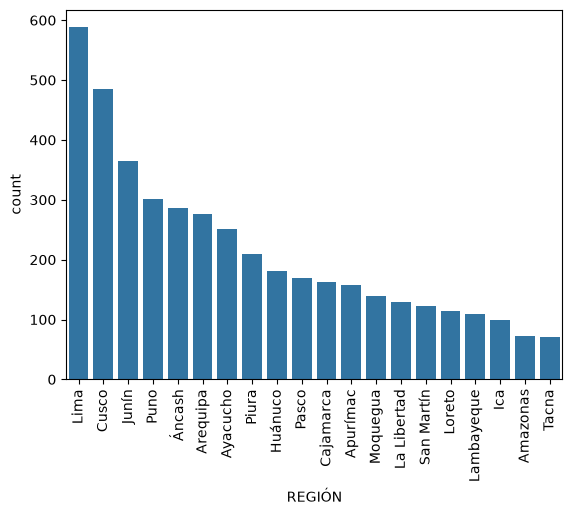

In [ ]:
##### Analizando datos
#### Cuant
# display(df_3[cuant_vars_3].describe())

#### Cual
for col in cual_vars_3:
    cat_num = df_3[col].value_counts()[:20]
    print("graph for %s: total = %d" % (col, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()